Imports and configuration

In [31]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from census import Census
from us import states
import mapclassify as mc

# Replace with your own Census API key:
API_KEY = "c9cf843d2c297d7ad549b1be51dbcf62facce09c"
YEAR = 2023                    # ACS 5-year data
VOT_REF = 23.10                 # $/hour – NYSDOT Downstate Local (2025)
ELASTICITY = 0.5                # income elasticity of value of time
NYC_COUNTIES = ["005","047","061","081","085"]   # Bronx, Kings, Manhattan, Queens, Richmond
JFK_LON, JFK_LAT = -73.7781, 40.6413              # JFK coordinates


Download ACS data for NYC census tracts

In [32]:
c = Census(API_KEY)

vars_dict = {
    "B19013_001E": "median_household_income",
    "B01003_001E": "population_total",
    # Education
    "B15003_022E": "bachelor",
    "B15003_023E": "master",
    "B15003_024E": "professional",
    "B15003_025E": "doctorate",
    # Occupations
    "C24010_002E": "management_business_finance",
    "C24010_010E": "computer_engineering_science",
    "C24010_018E": "education_legal_community_service_arts",
    "C24010_026E": "healthcare_practitioners",
}

frames = []
for cnty in NYC_COUNTIES:
    data = c.acs5.state_county_tract(list(vars_dict.keys()), states.NY.fips, cnty, Census.ALL, year=YEAR)
    frames.append(pd.DataFrame(data))

df = pd.concat(frames, ignore_index=True).rename(columns=vars_dict)
df["GEOID"] = df["state"] + df["county"] + df["tract"]

Clean and compute socioeconomic shares

In [33]:
df["median_household_income"] = pd.to_numeric(df["median_household_income"], errors="coerce")
df = df[df["median_household_income"] > 0].copy()

df["pop"] = pd.to_numeric(df["population_total"], errors="coerce").fillna(0)

# Education share
edu_cols = ["bachelor", "master", "professional", "doctorate"]
df["share_bach_plus"] = df[edu_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1) / df["pop"]

# Occupation share (management/professional jobs)
occ_cols = [
    "management_business_finance",
    "computer_engineering_science",
    "education_legal_community_service_arts",
    "healthcare_practitioners",
]
df["share_mgmt_prof"] = df[occ_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1) / df["pop"]

Compute Value of Time per tract

In [34]:
# --- Compute Value of Time per tract (simplified) ---
INCOME_REF = df["median_household_income"].mean()

VOT_REF = 23.10      # $/hour, NYSDOT Downstate Local (2023)
ELASTICITY = 0.5     # income elasticity (Small, 2012)

# Personal VoT (income-based)
df["vot_personal"] = VOT_REF * (df["median_household_income"] / INCOME_REF) ** ELASTICITY

cols_out = ["GEOID", "median_household_income", "share_bach_plus", "share_mgmt_prof", "vot_personal"]
df[cols_out].to_csv("nyc_value_of_time_by_tract.csv", index=False)

print("Saved nyc_value_of_time_by_tract.csv with", len(df), "tracts")

Saved nyc_value_of_time_by_tract.csv with 2192 tracts


Load tract geometries

In [35]:
tracts = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_36_tract_500k.zip")
tracts = tracts[tracts["COUNTYFP"].isin(NYC_COUNTIES)].copy()
tracts["GEOID"] = tracts["GEOID"].astype(str)

# Merge geometry with VoT data
gdf = tracts.merge(df[cols_out], on="GEOID", how="left")
gdf = gdf.to_crs(epsg=3857)  # Web Mercator for plotting

Prepare classification and color bins

In [36]:
# --- Prepare classification and color bins ---
series = gdf["vot_personal"]
classifier = mc.Quantiles(series, k=5)
gdf["vot_class"] = classifier.yb

labels = [f"{classifier.bins[i-1]:.1f}–{classifier.bins[i]:.1f}" for i in range(1, len(classifier.bins))]
print("VoT quantile bins:", labels)

VoT quantile bins: ['18.5–21.3', '21.3–23.9', '23.9–27.5', '27.5–nan']


Plot NYC map with JFK marker

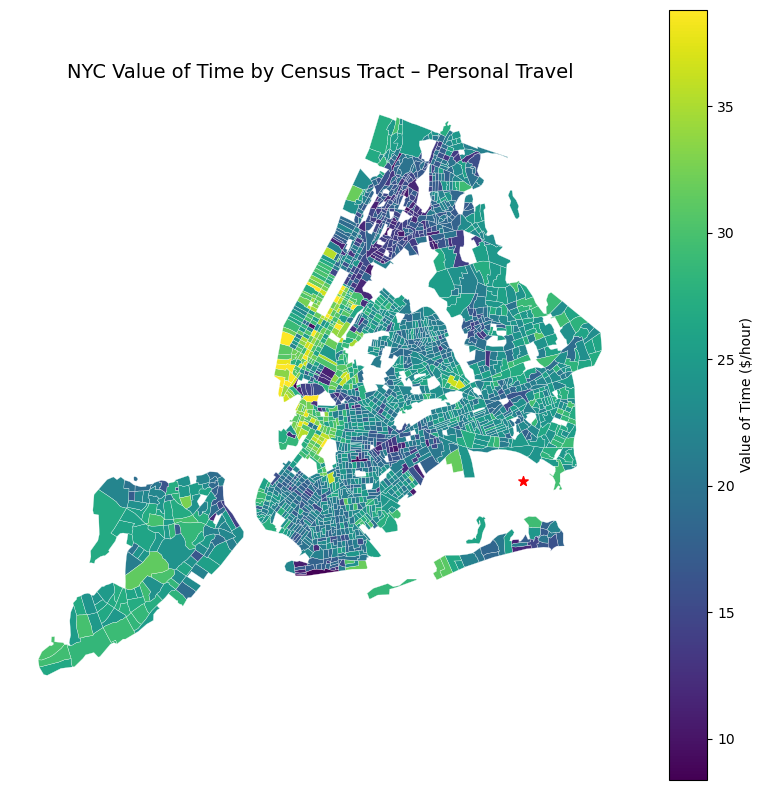

In [37]:
# --- Plot NYC map with JFK marker ---
fig, ax = plt.subplots(figsize=(10,10))
gdf.plot(
    column="vot_personal",
    cmap="viridis",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"label":"Value of Time ($/hour)"},
    ax=ax
)

# Plot JFK
jfk = gpd.GeoDataFrame(geometry=gpd.points_from_xy([JFK_LON], [JFK_LAT]), crs="EPSG:4326").to_crs(epsg=3857)
jfk.plot(ax=ax, markersize=50, color="red", marker="*", zorder=5)
ax.set_axis_off()
ax.set_title("NYC Value of Time by Census Tract – Personal Travel", fontsize=14)
plt.show()

Plot VoT with OSM basemap

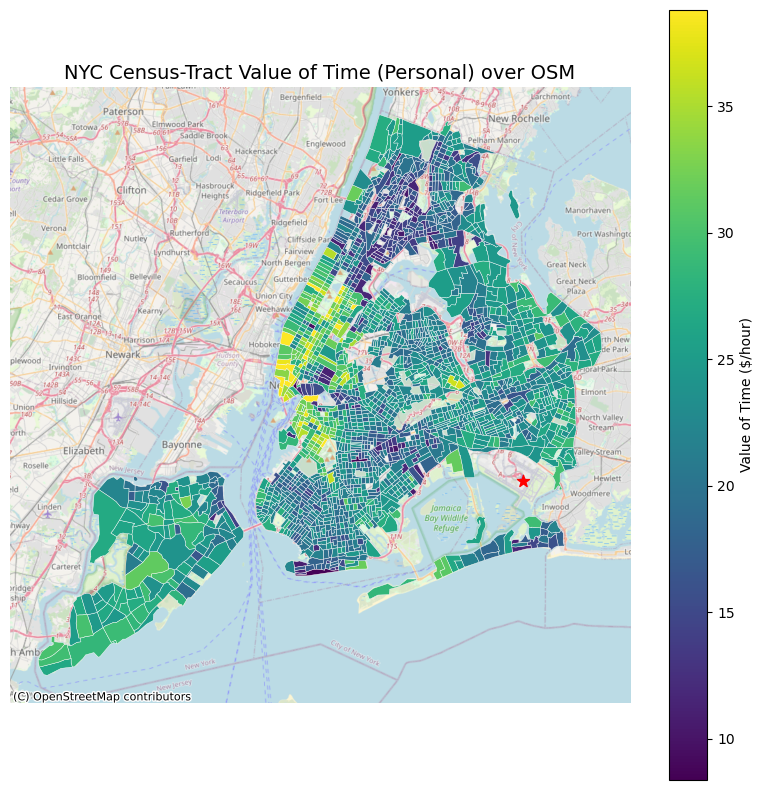

In [38]:
# --- Plot VoT over OSM basemap ---
import contextily as ctx

gdf_merc = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10,10))
gdf_merc.plot(
    column="vot_personal",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={"label":"Value of Time ($/hour)"},
    ax=ax
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)

jfk_merc = jfk.to_crs(epsg=3857)
jfk_merc.plot(ax=ax, marker="*", color="red", markersize=80, zorder=5)

ax.set_title("NYC Census-Tract Value of Time (Personal) over OSM", fontsize=14)
ax.axis("off")
plt.show()

Add business VoT and mixed VoT

In [39]:
# --- Add Business VoT and Mixed VoT ---

# 1. Ratio (USDOT 2024)
S_BIZ = 32.30 / 17.90  # ≈ 1.806

# 2. Business VoT
df["vot_business"] = S_BIZ * df["vot_personal"]

# 3. Business-share proxy (from management/professional share)
pi_raw = df["share_mgmt_prof"].fillna(df["share_mgmt_prof"].median())
pi_norm = (pi_raw - pi_raw.min()) / (pi_raw.max() - pi_raw.min() + 1e-9)
df["biz_share_pi"] = 0.05 + 0.30 * pi_norm  # 5%–35%

# 4. Mixed VoT
df["vot_mixed"] = (1 - df["biz_share_pi"]) * df["vot_personal"] + df["biz_share_pi"] * df["vot_business"]

# Save
df[["GEOID","median_household_income","share_bach_plus","share_mgmt_prof",
     "vot_personal","vot_business","biz_share_pi","vot_mixed"]
  ].to_csv("nyc_vot_by_tract_personal_business_mixed.csv", index=False)

print("Saved nyc_vot_by_tract_personal_business_mixed.csv")

Saved nyc_vot_by_tract_personal_business_mixed.csv


Quick comparison plot (personal vs business)

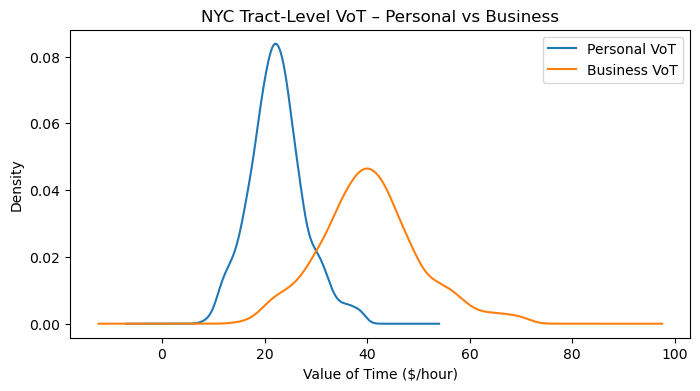

In [40]:
# --- Compare VoT distributions ---
fig, ax = plt.subplots(figsize=(8,4))
df["vot_personal"].plot(kind="kde", ax=ax, label="Personal VoT")
df["vot_business"].plot(kind="kde", ax=ax, label="Business VoT")
ax.set_xlabel("Value of Time ($/hour)")
ax.set_title("NYC Tract-Level VoT – Personal vs Business")
ax.legend()
plt.show()

Map business VoT

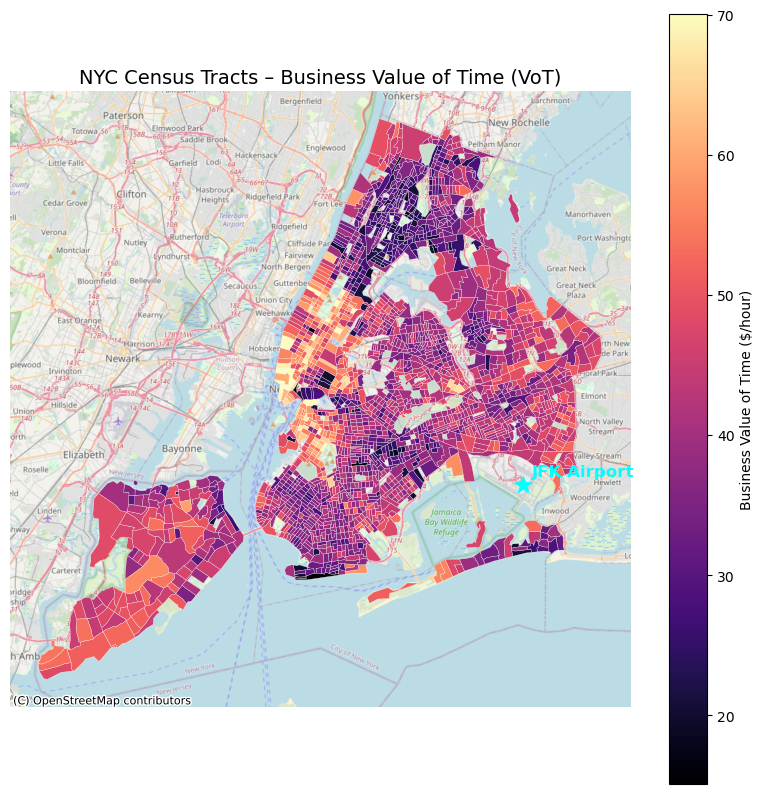

In [41]:
# --- Block C: Map business VoT ---
gdf_biz = gdf.merge(df[["GEOID","vot_business"]], on="GEOID", how="left")
gdf_biz = gdf_biz.to_crs(epsg=3857)  # reproject for OSM basemap

fig, ax = plt.subplots(figsize=(10,10))

# Choropleth for business VoT
gdf_biz.plot(
    column="vot_business",
    cmap="magma",                     # rich dark-to-bright gradient
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Business Value of Time ($/hour)"},
    ax=ax
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)

# Plot JFK star marker
jfk_merc = jfk.to_crs(epsg=3857)
jfk_merc.plot(ax=ax, marker="*", color="cyan", markersize=150, zorder=5)

# Label JFK
jfk_coords = jfk_merc.geometry.iloc[0].coords[0]
ax.text(jfk_coords[0] + 1000, jfk_coords[1] + 1000, "JFK Airport",
        color="cyan", fontsize=12, fontweight="bold")

# Formatting
ax.set_axis_off()
ax.set_title("NYC Census Tracts – Business Value of Time (VoT)", fontsize=14)
plt.show()

In [42]:
# --- Block 1: Merge mixed VoT with geometry ---
gdf_mixed = gdf.merge(df[["GEOID", "vot_mixed"]], on="GEOID", how="left")
gdf_mixed = gdf_mixed.to_crs(epsg=3857)  # for mapping on basemaps if needed

print("Number of tracts with mixed VoT:", gdf_mixed["vot_mixed"].notna().sum())


Number of tracts with mixed VoT: 2192


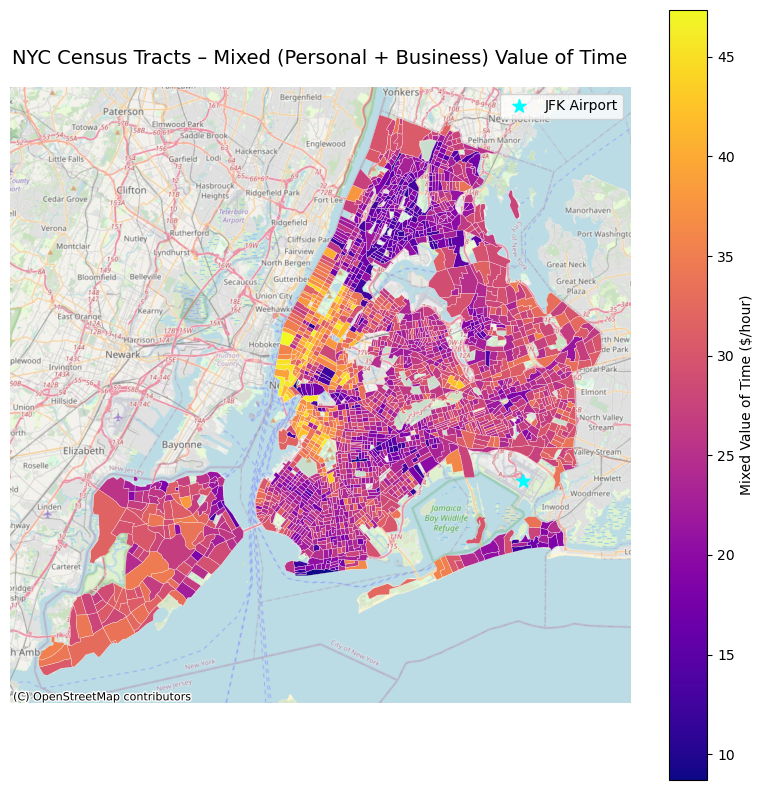

In [43]:
# --- Block 2: Map Mixed VoT by Census Tract ---
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10,10))
gdf_mixed.plot(
    column="vot_mixed",
    cmap="plasma",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"label":"Mixed Value of Time ($/hour)"},
    ax=ax
)

# Add OSM basemap for context
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)

# Optional: mark JFK
jfk_merc = jfk.to_crs(epsg=3857)
jfk_merc.plot(ax=ax, marker="*", color="cyan", markersize=100, zorder=5, label="JFK Airport")

ax.set_title("NYC Census Tracts – Mixed (Personal + Business) Value of Time", fontsize=14)
ax.legend()
ax.axis("off")
plt.show()


Read Trip Data

In [2]:
import pandas as pd

# --- Load February 2019 Uber/TLC trip data ---
trips = pd.read_csv("filtered_data/filtered_data_02.csv")

print("Loaded", len(trips), "trips")
print(trips.head())


Loaded 2 trips
          version https://git-lfs.github.com/spec/v1
0  oid sha256:c7450f502fb6ec60cf47c24e60ef1734996...
1                                      size 68880570
